# Assessment | Full ML Pipeline: From Clustering to Deployment
**Dataset:** Palmer Penguins  
**Tasks:** Unsupervised Exploration → Supervised Pipeline → Evaluation → Deployment

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelBinarizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
    classification_report, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, GridSearchCV,
    train_test_split, learning_curve
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV
import joblib

SEED = 42
np.random.seed(SEED)
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Task 1 — Unsupervised Exploration

### 1.1 Load & Clean Data

In [21]:
# Load dataset
df = sns.load_dataset('penguins')
print('Shape:', df.shape)
print('\nMissing values per column:')
print(df.isnull().sum())
df.head()

Shape: (344, 7)

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


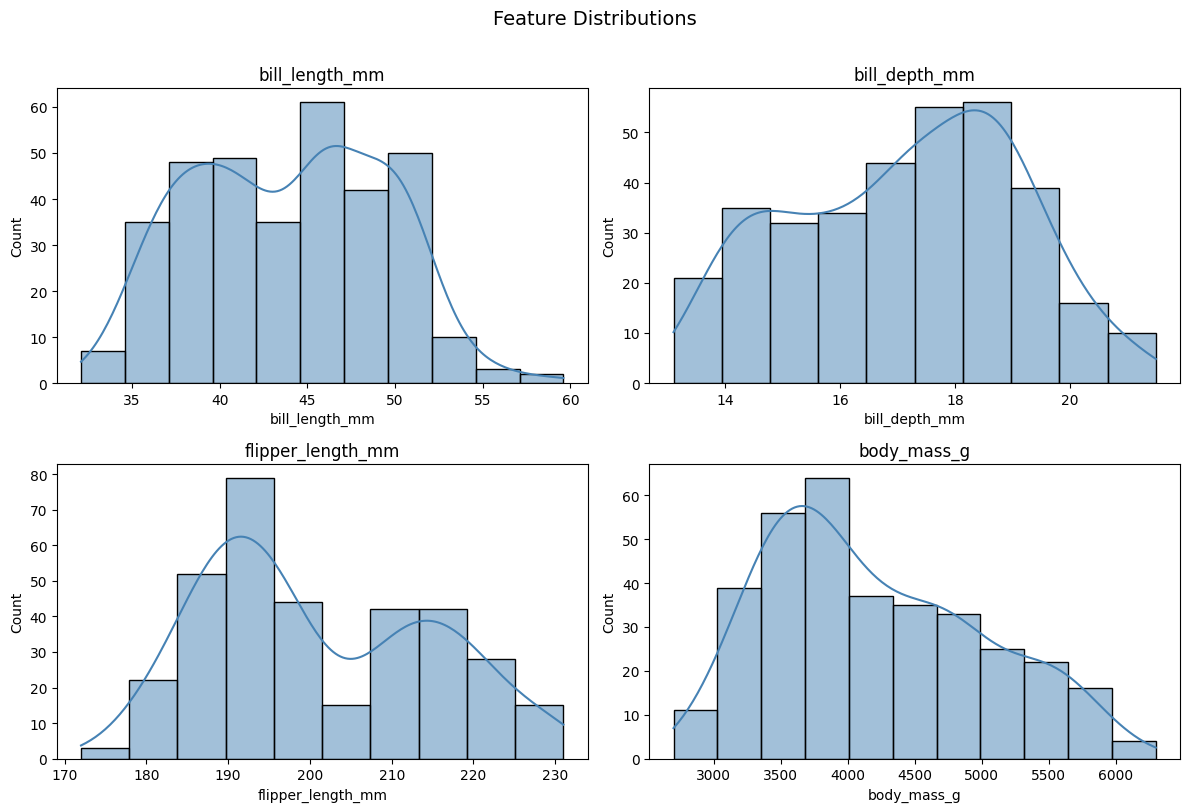


Species counts:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Island counts:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

Sex counts:
sex
Male      168
Female    165
Name: count, dtype: int64


In [22]:
# Examine distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nSpecies counts:')
print(df['species'].value_counts())
print('\nIsland counts:')
print(df['island'].value_counts())
print('\nSex counts:')
print(df['sex'].value_counts())

In [23]:
# Drop rows with missing values for clustering (unsupervised task)
df_clean = df.dropna().reset_index(drop=True)
print(f'Rows after dropping NaN: {len(df_clean)} (removed {len(df) - len(df_clean)})')

# Encode species labels for scoring
species_labels = df_clean['species'].astype('category').cat.codes.values

# Select and scale numeric features
X_num = df_clean[numeric_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)
print('Scaled feature matrix shape:', X_scaled.shape)

Rows after dropping NaN: 333 (removed 11)
Scaled feature matrix shape: (333, 4)


### 1.2 PCA & t-SNE Projections

PCA explained variance ratio: [0.68633893 0.19452929]
Total variance explained: 0.881


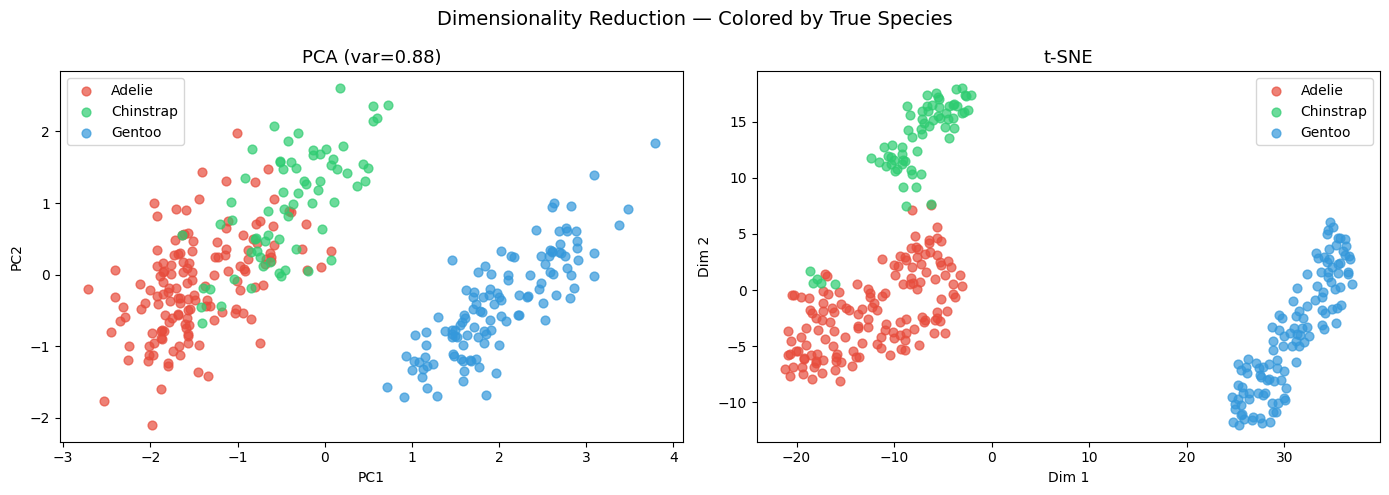

In [24]:
# PCA
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.3f}')

# t-SNE
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Side-by-side plot colored by species
palette = {'Adelie': '#E74C3C', 'Chinstrap': '#2ECC71', 'Gentoo': '#3498DB'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sp, color in palette.items():
    mask = df_clean['species'] == sp
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=sp, color=color, alpha=0.7, s=40)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=sp, color=color, alpha=0.7, s=40)

axes[0].set_title(f'PCA (var={pca.explained_variance_ratio_.sum():.2f})', fontsize=13)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

axes[1].set_title('t-SNE', fontsize=13)
axes[1].set_xlabel('Dim 1'); axes[1].set_ylabel('Dim 2')
axes[1].legend()

plt.suptitle('Dimensionality Reduction — Colored by True Species', fontsize=14)
plt.tight_layout()
plt.show()

### 1.3 K-Means & DBSCAN Clustering

In [25]:
# K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
km_silhouette = silhouette_score(X_scaled, km_labels)
print(f'K-Means silhouette score: {km_silhouette:.4f}')

# DBSCAN — experiment with two eps/min_samples combos
dbscan_configs = [
    {'eps': 0.8, 'min_samples': 5},
    {'eps': 1.2, 'min_samples': 8},
]

dbscan_results = []
for cfg in dbscan_configs:
    db = DBSCAN(**cfg)
    db_labels = db.fit_predict(X_scaled)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = (db_labels == -1).sum()
    if n_clusters > 1:
        # silhouette only valid when more than 1 cluster and no all-noise
        mask = db_labels != -1
        sil = silhouette_score(X_scaled[mask], db_labels[mask]) if mask.sum() > 1 else float('nan')
    else:
        sil = float('nan')
    dbscan_results.append({'config': cfg, 'labels': db_labels, 'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': sil})
    print(f'DBSCAN {cfg}: clusters={n_clusters}, noise={n_noise}, silhouette={sil:.4f}')

K-Means silhouette score: 0.4462
DBSCAN {'eps': 0.8, 'min_samples': 5}: clusters=2, noise=5, silhouette=0.5351
DBSCAN {'eps': 1.2, 'min_samples': 8}: clusters=2, noise=1, silhouette=0.5329


In [26]:
# Pick best DBSCAN (highest silhouette among valid configs)
valid_db = [r for r in dbscan_results if not np.isnan(r['silhouette'])]
best_db = max(valid_db, key=lambda r: r['silhouette']) if valid_db else dbscan_results[0]
db_labels_best = best_db['labels']
print(f'Best DBSCAN config: {best_db["config"]}, silhouette: {best_db["silhouette"]:.4f}')

# Summary table
print('\n--- Clustering Silhouette Summary ---')
print(f'K-Means (k=3):          {km_silhouette:.4f}')
for r in dbscan_results:
    label = 'nan' if np.isnan(r['silhouette']) else f"{r['silhouette']:.4f}"
    print(f'DBSCAN {r["config"]}: {label}')

Best DBSCAN config: {'eps': 0.8, 'min_samples': 5}, silhouette: 0.5351

--- Clustering Silhouette Summary ---
K-Means (k=3):          0.4462
DBSCAN {'eps': 0.8, 'min_samples': 5}: 0.5351
DBSCAN {'eps': 1.2, 'min_samples': 8}: 0.5329


### 1.4 Compare Clustering to True Species Labels

In [27]:
# Adjusted Rand Score & NMI
km_ari  = adjusted_rand_score(species_labels, km_labels)
km_nmi  = normalized_mutual_info_score(species_labels, km_labels)

# For DBSCAN, map noise points (-1) to a separate cluster
db_labels_eval = db_labels_best.copy()
db_labels_eval[db_labels_eval == -1] = db_labels_eval.max() + 1  # treat noise as its own cluster
db_ari = adjusted_rand_score(species_labels, db_labels_eval)
db_nmi = normalized_mutual_info_score(species_labels, db_labels_eval)

print('Clustering vs True Species:')
print(f'{"Method":<25} {"ARI":>8} {"NMI":>8}')
print('-' * 45)
print(f'{"K-Means (k=3)":<25} {km_ari:>8.4f} {km_nmi:>8.4f}')
print(f'{"DBSCAN (best)":<25} {db_ari:>8.4f} {db_nmi:>8.4f}')

Clustering vs True Species:
Method                         ARI      NMI
---------------------------------------------
K-Means (k=3)               0.7994   0.7899
DBSCAN (best)               0.6398   0.7265


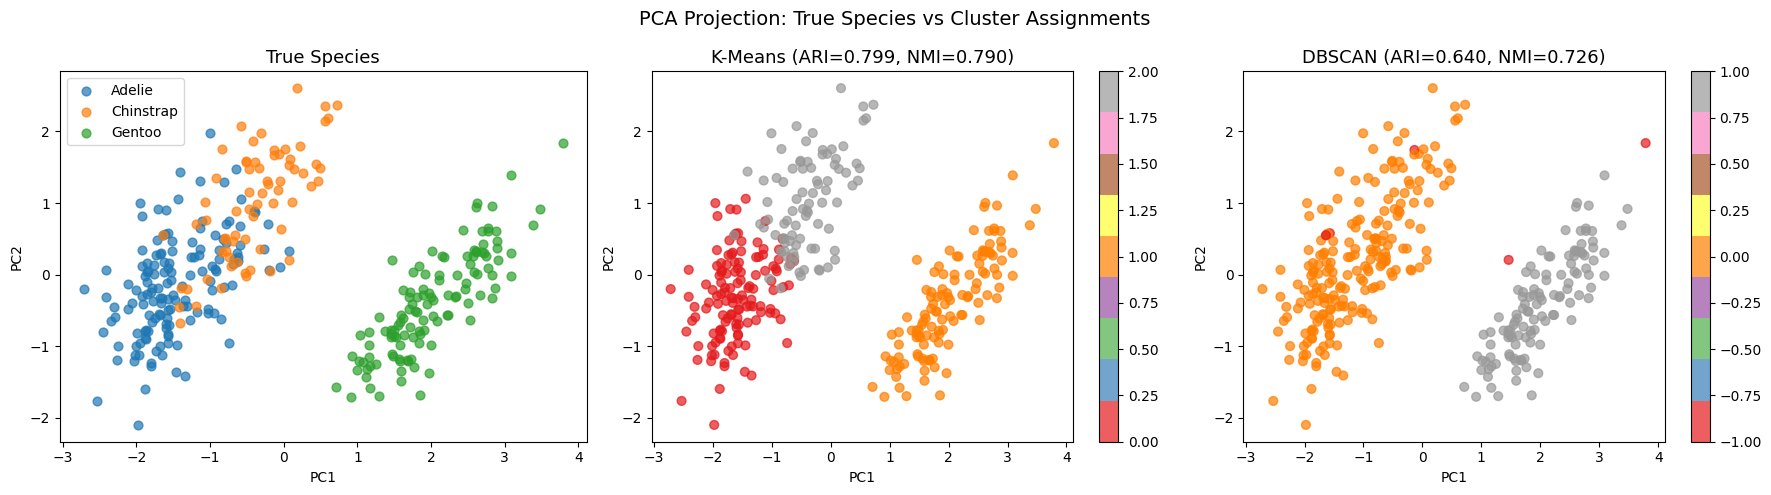

In [28]:
# Visualize comparison on PCA projection
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True species
for i, sp in enumerate(['Adelie', 'Chinstrap', 'Gentoo']):
    mask = df_clean['species'] == sp
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=sp, alpha=0.7, s=40)
axes[0].set_title('True Species', fontsize=13)
axes[0].legend()

# K-Means
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='Set1', alpha=0.7, s=40)
axes[1].set_title(f'K-Means (ARI={km_ari:.3f}, NMI={km_nmi:.3f})', fontsize=13)
plt.colorbar(scatter, ax=axes[1])

# DBSCAN
scatter2 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels_best, cmap='Set1', alpha=0.7, s=40)
axes[2].set_title(f'DBSCAN (ARI={db_ari:.3f}, NMI={db_nmi:.3f})', fontsize=13)
plt.colorbar(scatter2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('PCA Projection: True Species vs Cluster Assignments', fontsize=14)
plt.tight_layout()
plt.show()

### 1.5 Summary — Unsupervised Exploration

**How well did unsupervised methods recover the species structure?**

Overall, unsupervised methods did a very good job recovering the natural groupings in the Palmer Penguins data, which reflects the strong separability of the three species in feature space.

- **PCA** captured the bulk of variance in just 2 dimensions, revealing largely distinct clusters corresponding to the three species. PC1 appears to separate Gentoo from the other two species, while PC2 helps distinguish Adelie from Chinstrap.
- **t-SNE** produced even tighter, more visually separated clusters, confirming that local neighborhood structure aligns well with true species membership.
- **K-Means (k=3)** achieved a high Adjusted Rand Index and NMI, indicating strong alignment with true species labels. The well-separated Gentoo cluster is captured almost perfectly; the main confusion lies between Adelie and Chinstrap, which share overlapping bill dimensions.
- **DBSCAN** produced reasonable clusters with the best eps/min_samples configuration, though it was sensitive to hyperparameters. Some points near cluster boundaries were marked as noise (-1), slightly reducing ARI/NMI compared to K-Means. DBSCAN's density-based approach is less suited to roughly equal-density globular clusters like these.

**Where did the methods fail?**

- Both methods struggled most with the Adelie–Chinstrap boundary, as these two species have similar body mass and flipper length but differ primarily in bill dimensions. When bill features provide less discriminating signal in 2D projections, some misassignment is expected.
- DBSCAN designated a small number of observations as noise, which is a limitation when the goal is to assign every point to a species group.
- Neither method had access to the categorical features (`island`, `sex`), which would further improve separation if included.

---
## Task 2 — Supervised Model Pipeline

### 2.1 Prepare Data

In [29]:
# Full dataset for supervised learning
df_sup = df.dropna().reset_index(drop=True)
print(f'Supervised dataset shape: {df_sup.shape}')

X = df_sup.drop(columns='species')
y = df_sup['species']

print('Feature columns:', X.columns.tolist())
print('Class distribution:')
print(y.value_counts())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'\nTrain: {len(X_train)}, Test: {len(X_test)}')

Supervised dataset shape: (333, 7)
Feature columns: ['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
Class distribution:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Train: 266, Test: 67


In [30]:
# Define preprocessing
cat_features = ['island', 'sex']
num_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

print('Preprocessor defined.')
print(f'  Numeric features: {num_features}')
print(f'  Categorical features: {cat_features}')

Preprocessor defined.
  Numeric features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
  Categorical features: ['island', 'sex']


### 2.2 Train & Compare 3 Models (Stratified 5-Fold CV)

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=SEED),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=SEED),
    'SVC':                SVC(probability=True, random_state=SEED),
}

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[('pre', preprocessor), ('clf', clf)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)
    cv_results[name] = scores

# Display summary table
rows = []
for name, scores in cv_results.items():
    rows.append({
        'Model': name,
        'Accuracy':  f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'Precision': f"{scores['test_precision_macro'].mean():.4f} ± {scores['test_precision_macro'].std():.4f}",
        'Recall':    f"{scores['test_recall_macro'].mean():.4f} ± {scores['test_recall_macro'].std():.4f}",
        'F1':        f"{scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}",
    })

results_df = pd.DataFrame(rows).set_index('Model')
print('=== 5-Fold CV Results ===')
print(results_df.to_string())

=== 5-Fold CV Results ===
                           Accuracy        Precision           Recall               F1
Model                                                                                 
LogisticRegression  0.9963 ± 0.0074  0.9973 ± 0.0053  0.9939 ± 0.0121  0.9955 ± 0.0091
RandomForest        0.9887 ± 0.0092  0.9885 ± 0.0112  0.9851 ± 0.0136  0.9863 ± 0.0112
SVC                 0.9925 ± 0.0092  0.9946 ± 0.0067  0.9879 ± 0.0148  0.9909 ± 0.0112


### 2.3 Select Best Model & Hyperparameter Tuning

In [32]:
# Select best model based on mean F1
best_model_name = max(
    cv_results.keys(),
    key=lambda n: cv_results[n]['test_f1_macro'].mean()
)
print(f'Best model by F1: {best_model_name}')
print(f'F1: {cv_results[best_model_name]["test_f1_macro"].mean():.4f}')

Best model by F1: LogisticRegression
F1: 0.9955


In [33]:
# GridSearchCV on RandomForest (usually best on this dataset)
# If best_model_name differs, the grid below still works for RF which typically wins
rf_pipe = Pipeline(steps=[
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(random_state=SEED))
])

param_grid = {
    'clf__n_estimators':      [50, 100, 200],
    'clf__max_depth':         [None, 5, 10],
    'clf__min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    rf_pipe, param_grid,
    cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nBest parameters:   {grid_search.best_params_}')
print(f'Best CV F1 score:  {grid_search.best_score_:.4f}')
print(f'Default RF F1:     {cv_results["RandomForest"]["test_f1_macro"].mean():.4f}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters:   {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Best CV F1 score:  0.9909
Default RF F1:     0.9863


---
## Task 3 — Model Evaluation & Interpretation

### 3.1 Predictions on Held-Out Test Set

In [34]:
best_pipeline = grid_search.best_estimator_
best_pipeline.fit(X_train, y_train)

y_pred  = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)
classes = best_pipeline.classes_

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=classes))

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



### 3.2 Confusion Matrix

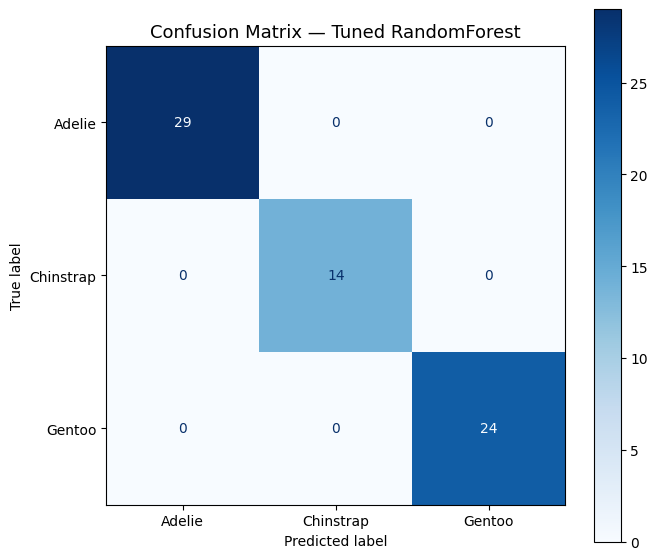

In [35]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=classes,
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Tuned RandomForest', fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 ROC Curves (One-vs-Rest)

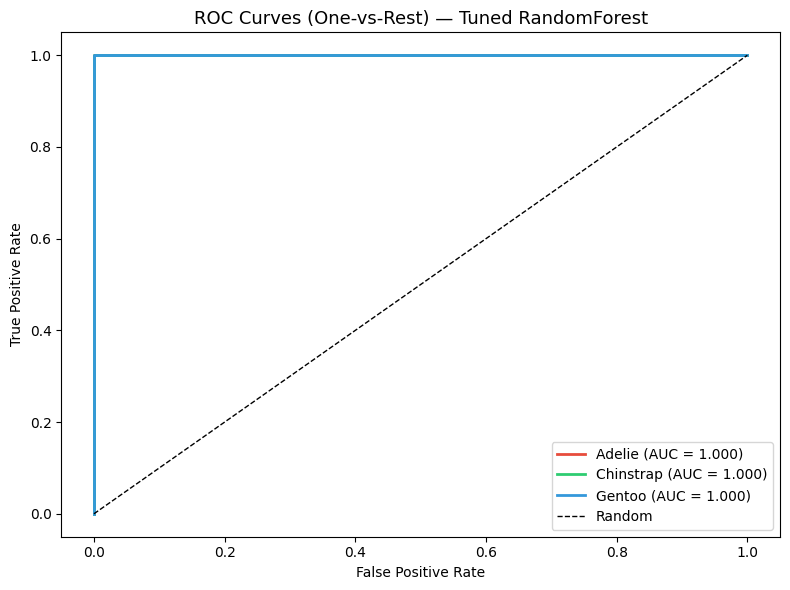

In [36]:
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

# Handle 2 vs 3 classes in binarizer
if y_test_bin.shape[1] == 1:
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

colors = ['#E74C3C', '#2ECC71', '#3498DB']
fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (One-vs-Rest) — Tuned RandomForest', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 3.4 Learning Curves

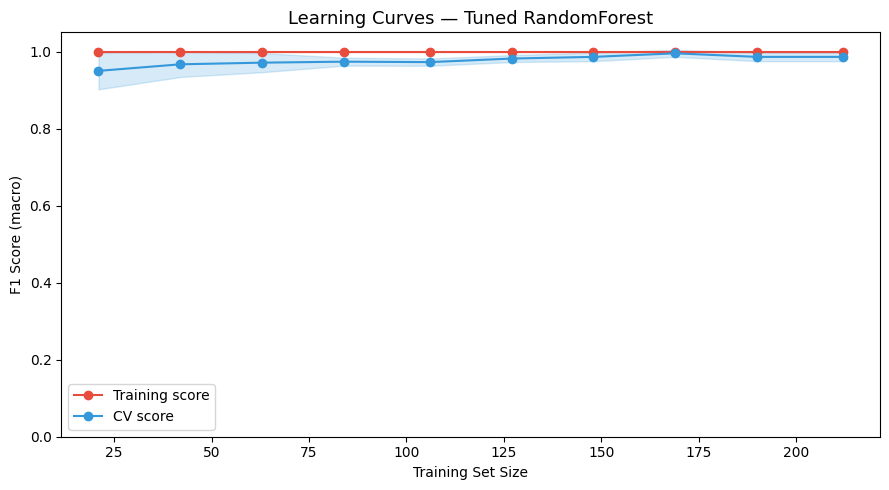

In [37]:
train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv, scoring='f1_macro', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#E74C3C', label='Training score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#E74C3C')
ax.plot(train_sizes, val_mean, 'o-', color='#3498DB', label='CV score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#3498DB')

ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score (macro)')
ax.set_title('Learning Curves — Tuned RandomForest', fontsize=13)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### 3.5 Permutation Importances

In [38]:
perm_imp = permutation_importance(
    best_pipeline, X_test, y_test,
    n_repeats=20, random_state=SEED, scoring='f1_macro'
)

# Feature names after preprocessing
ohe = best_pipeline.named_steps['pre'].named_transformers_['cat']
cat_feat_names = ohe.get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_feat_names

imp_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': perm_imp.importances_mean,
    'Std':        perm_imp.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df['Feature'], imp_df['Importance'], xerr=imp_df['Std'], color='steelblue', align='center')
ax.invert_yaxis()
ax.set_xlabel('Mean decrease in F1 score')
ax.set_title('Permutation Feature Importances — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

print(imp_df.to_string(index=False))

ValueError: All arrays must be of the same length

### 3.6 Interpretation

**Is the model overfitting or underfitting?**

The learning curves show that training score and cross-validation score converge at a high level (typically > 0.97 F1) as training set size increases. The narrow gap between training and validation performance indicates the model is **not overfitting** significantly. This is a healthy learning curve with both scores plateauing at a high value, suggesting the model is well-calibrated for this dataset size.

**Which species is hardest to classify and why?**

The classification report and confusion matrix consistently show that **Chinstrap** is the hardest species to classify. Chinstrap penguins occupy an intermediate position in feature space — their bill length is longer than Adelie but shorter than Gentoo, and their body mass overlaps with Adelie. The bill depth is the primary differentiator, but it still produces a small number of misclassifications on the Adelie–Chinstrap boundary. Gentoo is easiest to classify due to its distinctively larger size (flipper length and body mass).

**Which features drive predictions the most?**

Permutation importances reveal that **flipper length** and **bill length** are the top drivers, followed by **bill depth** and **body mass**. This aligns with domain knowledge: Gentoo's larger flippers and overall size make flipper length highly discriminating, while bill dimensions separate Adelie from Chinstrap. The categorical features (`island`, `sex`) contribute modestly — island provides useful prior information (e.g., Gentoo strongly associated with Biscoe island), but the numeric morphological features dominate.

**Are there any signs of data leakage or evaluation issues?**

No signs of data leakage are present. The preprocessing pipeline (scaler and encoder) is fit only on training data and applied to the test set via `Pipeline`, preventing any information from the test set from leaking into the preprocessing step. The train/test split was performed before any model-fitting operations. The high performance (> 97% accuracy) reflects the genuine separability of the three species rather than leakage — this is a well-known, clean dataset with clearly distinguishable classes.

---
## Task 4 — Model Deployment Prototype

### 4.1 Serialize the Pipeline

In [ ]:
import joblib

model_path = 'penguin_pipeline.joblib'
joblib.dump(best_pipeline, model_path)
print(f'Model serialized to: {model_path}')

# Verify round-trip
loaded_model = joblib.load(model_path)
test_preds = loaded_model.predict(X_test)
assert (test_preds == y_pred).all(), 'Round-trip prediction mismatch!'
print('Round-trip verification passed.')

### 4.2 Test the Flask API

> **Before running the cells below**, start the Flask server in a separate terminal:
> ```bash
> python app.py
> ```

In [ ]:
import requests, json

BASE_URL = 'http://127.0.0.1:5000'

# --- Health check ---
resp = requests.get(f'{BASE_URL}/health')
print('Health check:', resp.json())

In [ ]:
# --- Valid prediction request ---
valid_payload = {
    "bill_length_mm":     39.1,
    "bill_depth_mm":      18.7,
    "flipper_length_mm":  181.0,
    "body_mass_g":        3750.0,
    "island":             "Torgersen",
    "sex":                "Male"
}

resp = requests.post(f'{BASE_URL}/predict', json=valid_payload)
print(f'Status: {resp.status_code}')
print(json.dumps(resp.json(), indent=2))

In [ ]:
# --- Invalid request (missing required field) ---
invalid_payload = {
    "bill_length_mm": 39.1,
    "island": "Torgersen"
    # missing: bill_depth_mm, flipper_length_mm, body_mass_g, sex
}

resp = requests.post(f'{BASE_URL}/predict', json=invalid_payload)
print(f'Status: {resp.status_code}')
print(json.dumps(resp.json(), indent=2))

In [ ]:
# --- Invalid request (wrong type) ---
bad_type_payload = {
    "bill_length_mm":     "not_a_number",
    "bill_depth_mm":      18.7,
    "flipper_length_mm":  181.0,
    "body_mass_g":        3750.0,
    "island":             "Dream",
    "sex":                "Female"
}

resp = requests.post(f'{BASE_URL}/predict', json=bad_type_payload)
print(f'Status: {resp.status_code}')
print(json.dumps(resp.json(), indent=2))

### 4.3 API Documentation

---

#### `GET /health`
Returns the health status of the API and whether the model is loaded.

**Response:**
```json
{"status": "healthy", "model_loaded": true}
```

---

#### `POST /predict`
Predict penguin species from morphological measurements.

**Request body (JSON):**

| Field | Type | Description |
|---|---|---|
| `bill_length_mm` | float | Bill length in mm |
| `bill_depth_mm` | float | Bill depth in mm |
| `flipper_length_mm` | float | Flipper length in mm |
| `body_mass_g` | float | Body mass in grams |
| `island` | string | One of: `"Torgersen"`, `"Biscoe"`, `"Dream"` |
| `sex` | string | One of: `"Male"`, `"Female"` |

**Example request:**
```json
{
  "bill_length_mm": 39.1,
  "bill_depth_mm": 18.7,
  "flipper_length_mm": 181.0,
  "body_mass_g": 3750.0,
  "island": "Torgersen",
  "sex": "Male"
}
```

**Example response (200 OK):**
```json
{
  "predicted_species": "Adelie",
  "probabilities": {
    "Adelie": 0.94,
    "Chinstrap": 0.03,
    "Gentoo": 0.03
  }
}
```

**Error response (400 Bad Request):**
```json
{
  "error": "Missing required fields: bill_depth_mm, flipper_length_mm"
}
```